In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


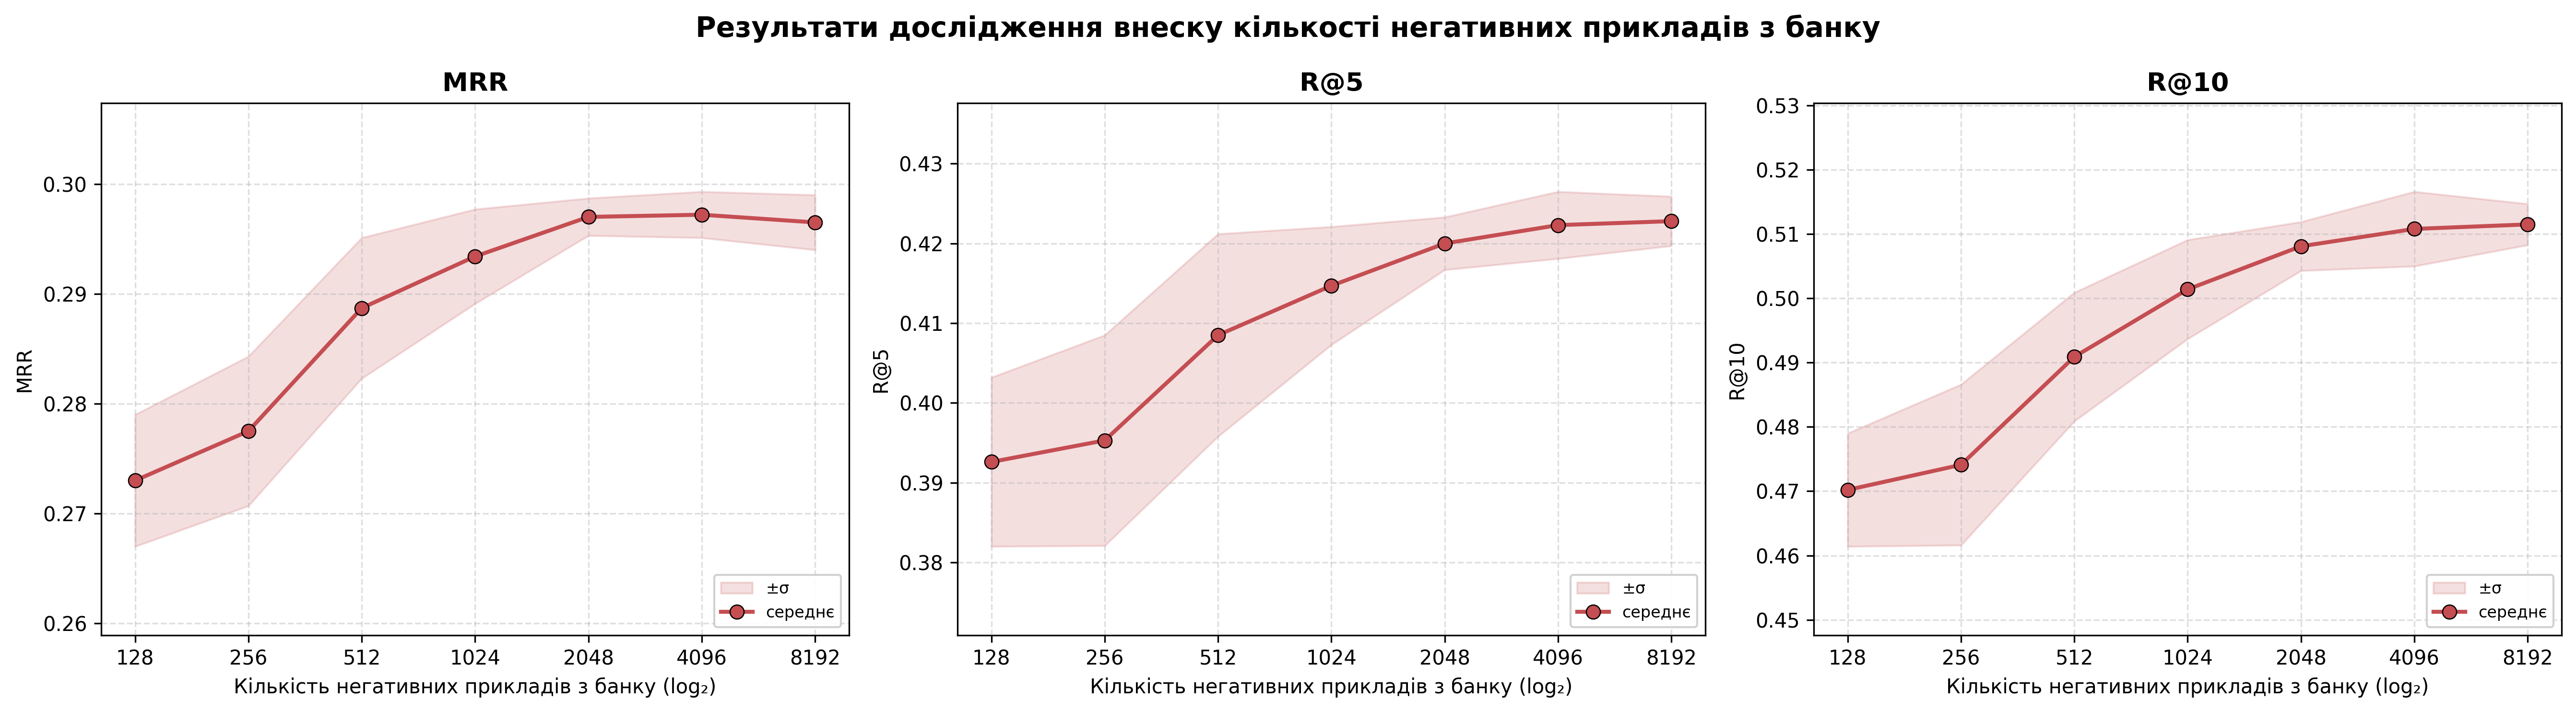

In [2]:
import matplotlib.pyplot as plt
import numpy as np

n_bank_neg = np.array([128, 256, 512, 1024, 2048, 4096, 8192])

mrr      = np.array([0.2730, 0.2775, 0.2887, 0.2934, 0.2970, 0.2972, 0.2965])
mrr_std  = np.array([0.0060, 0.0068, 0.0064, 0.0043, 0.0017, 0.0021, 0.0025])

r5       = np.array([0.3926, 0.3953, 0.4085, 0.4147, 0.4200, 0.4223, 0.4228])
r5_std   = np.array([0.0106, 0.0132, 0.0127, 0.0074, 0.0033, 0.0042, 0.0031])

r10      = np.array([0.4702, 0.4741, 0.4909, 0.5014, 0.5081, 0.5108, 0.5115])
r10_std  = np.array([0.0088, 0.0125, 0.0100, 0.0077, 0.0038, 0.0058, 0.0032])

metrics = [
    ('MRR',    mrr, mrr_std),
    ('R@5',  r5,  r5_std),
    ('R@10', r10, r10_std),
]

chosen_n_neg = 4096
line_color = '#C44E52'
band_color = '#C44E52'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, dpi=300)

for ax, (name, vals, errs) in zip(axes, metrics):
    ax.fill_between(n_bank_neg, vals - errs, vals + errs,
                    color=band_color, alpha=0.18, label='±σ')
    ax.plot(n_bank_neg, vals, marker='o', color=line_color,
            linewidth=2, markersize=7, markeredgecolor='black',
            markeredgewidth=0.6, label='середнє')

    idx_full = int(np.where(n_bank_neg == chosen_n_neg)[0][0])
    full_val = vals[idx_full]

    ax.set_xscale('log', base=2)
    ax.set_xticks(n_bank_neg)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v)}'))
    ax.minorticks_off()

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Кількість негативних прикладів з банку (log₂)')
    ax.set_ylabel(name)
    ax.grid(True, which='both', linestyle='--', alpha=0.4)

    lo = float((vals - errs).min())
    hi = float((vals + errs).max())
    pad = (hi - lo) * 0.25
    ax.set_ylim(lo - pad, hi + pad)

    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)

fig.suptitle('Результати дослідження внеску кількості негативних прикладів з банку',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()